In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Business Understanding**

### **Problem Background**

Bike-Sharing merupakan suatu model bisnis yang menjadi inovasi dalam bisnis rental sepeda. Bisnis *Bike-Sharing* memiliki sistem yang terintegrasi, mulai dari membership, rental, hingga pengembalian sepeda. Saat ini, terdapat lebih dari 500 program *Bike-Sharing* di seluruh dunia, menjadikan hal tersebut sebuah bisnis dengan peran penting dalam keberlangsungan lalu lintas, lingkungan, dan isu kesehatan di masyarakat, khususnya di area perkotaan.

- Berdasarkan Badan Pusat Statistik (2025), 60,7% penduduk Indonesia kini tinggal di wilayah perkotaan, terdapat peningkatan 10% dibandingkan satu dekade sebelumnya. Urbanisasi yang meningkat berujung pada kepadatan lalu lintas, penggunaan sepeda berpotensi semakin relevan dan strategis.

- Menurut laporan dari Kualitas Udara Dunia IQAir (2022), pada tahun 2021, Indonesia menduduki peringkat ke-17 sebagai negara dengan tingkat polusi udara tertinggi di dunia, dengan konsentrasi PM2,5 mencapai 34,3 μg per meter kubik. Sepeda bisa menjadi transportasi alternatif yang ramah lingkungan, menekan jumlah karbon monoksida yang terkandung pada udara.

- Bersepeda dapat menjaga kesehatan jasmani karena dapat meningkatkan kebugaran dan kekebalan tubuh (Utomo, 2020). Sepeda adalah salah satu solusi terhadap isu kesehatan masyarakat yang murah, mudah diakses, dan menjadi bentuk upaya preventif terhadap berbagai penyakit kronis hingga gangguan mental.

***Demand* penggunaan sepeda akan mengalami tren kenaikan jangka panjang karena didorong oleh faktor-faktor tersebut.**

### **Problem Statement**

Tren penggunaan sepeda sebagai alat transportasi terus meningkat, namun sistem *Bike-Sharing* tetap menjadi bisnis yang penuh akan tantangan untuk bisa berlangsung. Sebagai contoh, berdasarkan laporan dari Kompas.com (2022), sejumlah layanan sewa sepeda yang tersebar di beberapa lokasi di Jakarta, kondisinya kini terbengkalai. 

Dibutuhkan strategi yang tepat oleh perusahaan agar dapat memiliki model bisnis dengan sistem yang optimal agar dapat menekan kerugian finansial, sistemik, dan operasional. Permintaan *Bike-Sharing* sangat sensitif terhadap faktor eksternal, seperti kondisi lingkungan, waktu, dan cuaca. Maka dari itu, perusahaan mengalami kesulitan dalam mengurangi pemborosan dalam aspek inventaris, rantai pasok, serta tenaga kerja.

### **Business Question**

Berdasarkan *Problem Statement* yang telah terdefinisi, pertanyaan bisnis yang perlu untuk dijawab adalah:

**Bagaimana permintaan konsumen terhadap *Bike-Sharing* ?**

### **Analytic Approach**

Dalam menjawab *Business Question* , pendekatan analisa yang akan dilakukan adalah dengan membangun model machine learning regresi yang mampu memberikan prediksi nilai numerik atau kontinu, yaitu demand peminjaman sepeda. Proses analisa harus kerangka kerja yang terstruktur, maka kita akan menggunakan metode CRISP-DM, dimana terdapat beberapa fase yang dilakukan secara berulang hingga mendapatkan hasil yang optimal.

![alt text](CRISP-DM_Process_Diagram.png)

### **Evaluation Metrics**

Metrik evaluasi yang akan digunakan untuk mengukur performa model adalah RMSE, MAE, dan MAPE.

- RMSE merupakan nilai akar dari rata-rata error kuadrat, semakin ekstrim suatu nilai error maka semakin tinggi nilai RMSE. Metrik ini dipilih karena RMSE memberikan bobot lebih terhadap nilai error yang tinggi sehingga dapat mengukur seberapa akurat model dalam melakukan prediksi jika terdapat outlier.
- MAE merupakan nilai error absolut tanpa mempertimbangkan outlier dan arah prediksi (overestimation atau underestimation) sehingga memberikan nilai yang lebih seimbang dan mudah untuk kebutuhan intepretasi.
- MAPE merupakan nilai persentase rata-rata error, metrik ini digunakan karena dapat mengukur seberapa jauh model melakukan kesalahan prediksi.

### **Refrensi**

- https://agridigi.fkp.unesa.ac.id/post/urbanisasi-dan-ketimpangan-sosial-di-indonesia-2025-antara-pusat-pertumbuhan-dan-pinggiran-terlupakan
- https://setkab.go.id/peningkatan-polusi-udara-di-indonesia-perspektif-ekonomi-berdasarkan-teori-freakonomics/
- https://etd.umy.ac.id/id/eprint/2127/
- https://megapolitan.kompas.com/read/2022/11/26/12032201/nasib-bike-sharing-di-jakarta-terbengkalai-dan-butuh-evaluasi

# **Data Analysis**

### **Data Understanding**

Dataset yang digunakan merupakan data historis penggunaan sistem *Bike-Sharing* selama 2 tahun

**Deskripsi Data**

| Kolom	| Deskripsi | Tipe Data |
|---|---|---|
| dtedays	| Tanggal data tersebut diambil | String |
| Season	| 1: Winter, 2: Spring, 3: Summer, 4: Fall| Integer |
| Hr	| Waktu jam data diambil (0 - 23) | Integer |
| Holiday	| 0: Tidak sedang hari libur, 1: Sedang hari libur | Integer |
| temp | Suhu udara dalam celcius yang telah dinormalisasi | Float |	
| Atemp | Suhu semu dalam celcius yang telah dinormalisasi | Float |
| Hum | Kelembapan udara yang telah dinormalisasi |	Float |
| Casual	| Jumlah pengguna yang tidak mendaftar | Integer |
| Registered	| Jumlah pengguna yang mendaftar | Integer |
| Cnt	| Jumlah total pengguna ( Casual + Registered) | Integer |
| Weathersit |	1: Cuaca cerah, 2: Cuaca berawan atau berkabut, 3: Terdapat Hujan gerimis, badai, atau bersalju, 4: Cuaca ekstrim, terdapat hujan besar, badai petir, dataran licin, atau berkabut | Integer |


### **Data Loading and Cleaning**

In [2]:
df = pd.read_csv('data_bike_sharing.csv')
df

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857
...,...,...,...,...,...,...,...,...,...,...,...
12160,2012-01-25,0.75,1,0,1,0.2273,0.24,7,14,243,257
12161,2012-07-06,0.62,1,0,3,0.7424,0.78,0,39,63,102
12162,2012-02-20,0.60,2,1,1,0.2121,0.24,5,0,6,6
12163,2012-03-31,0.77,2,0,2,0.4242,0.42,2,14,55,69


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      12165 non-null  object 
 1   hum         12165 non-null  float64
 2   weathersit  12165 non-null  int64  
 3   holiday     12165 non-null  int64  
 4   season      12165 non-null  int64  
 5   atemp       12165 non-null  float64
 6   temp        12165 non-null  float64
 7   hr          12165 non-null  int64  
 8   casual      12165 non-null  int64  
 9   registered  12165 non-null  int64  
 10  cnt         12165 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
df['dteday'] = df['dteday'].astype('datetime64[ns]')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      12165 non-null  datetime64[ns]
 1   hum         12165 non-null  float64       
 2   weathersit  12165 non-null  int64         
 3   holiday     12165 non-null  int64         
 4   season      12165 non-null  int64         
 5   atemp       12165 non-null  float64       
 6   temp        12165 non-null  float64       
 7   hr          12165 non-null  int64         
 8   casual      12165 non-null  int64         
 9   registered  12165 non-null  int64         
 10  cnt         12165 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(7)
memory usage: 1.0 MB


Dilakukan *Type Casting* terhadap kolom data dteday, mengubah tipe data string menjadi datetime. Hal ini bertujuan agar dataset dapat digunakan dalam proses EDA, membuat proses analisis menjadi lebih mudah

In [5]:
df.isnull().sum()

dteday        0
hum           0
weathersit    0
holiday       0
season        0
atemp         0
temp          0
hr            0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

Tidak ditemukan missing value dan data duplikat, sehingga tidak perlu dilakukan imputasi data dan data siap digunakan untuk tahapan analisa selanjutnya

### **Exploratory Data Analysis**

##### **Distribusi Data Cnt**

<Axes: xlabel='cnt', ylabel='Count'>

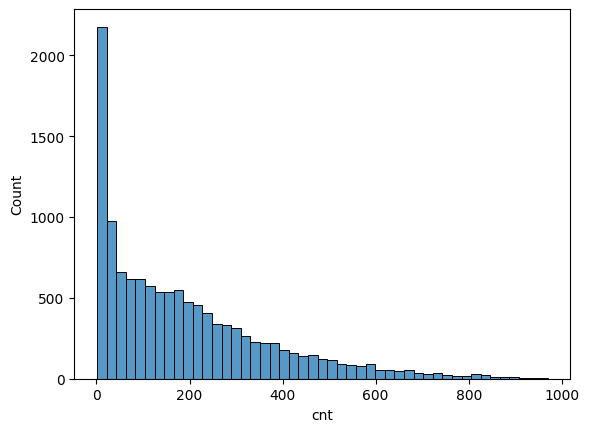

In [7]:
sns.histplot(data = df, x='cnt')

Plot histogram menunjukan bahwa terdapat *right-skewed* distribution pada distribusi data cnt

Data cnt tidak terdistribusi secara normal

##### **Tren Penggunaan Bike-Sharing**

C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_35468\4044703870.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_season, x='season', y='cnt', palette='Set1')
C:\Users\dwisanjani\AppData\Local\Temp\ipykernel_35468\4044703870.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Winter','Spring','Summer','Fall'])


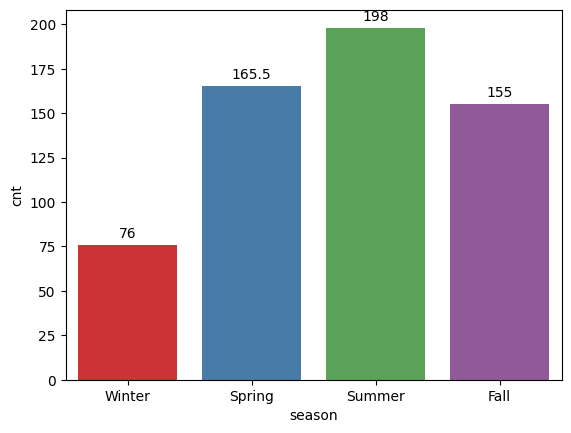

In [8]:
df_season = df.groupby('season')[['cnt']].median().reset_index()

ax = sns.barplot(data=df_season, x='season', y='cnt', palette='Set1')
for container in ax.containers:
    ax.bar_label(container, padding =3)
    
ax.set_xticklabels(['Winter','Spring','Summer','Fall'])
plt.show()

nilai total cnt tertinggi berada di season summer, sedangkan nilai total cnt terendah berada di season winter

jumlah peminjaman sepeda terbanyak terjadi ketika musim panas, peminjaman sepeda terendah terjadi saat musim dingin

In [9]:
df_holiday = df[['dteday','holiday','casual','registered','cnt']]
df_holiday.groupby('holiday')[['cnt']].median()

,cnt
holiday,
0,144.0
1,97.5


nilai median cnt ketika hari tidak libur lebih besar dibandingkan ketika sedang libur

area urban lebih padat ketika hari sedang tidak libur, semakin banyak orang di area, semakin tinggi peminjaman sepeda terjadi

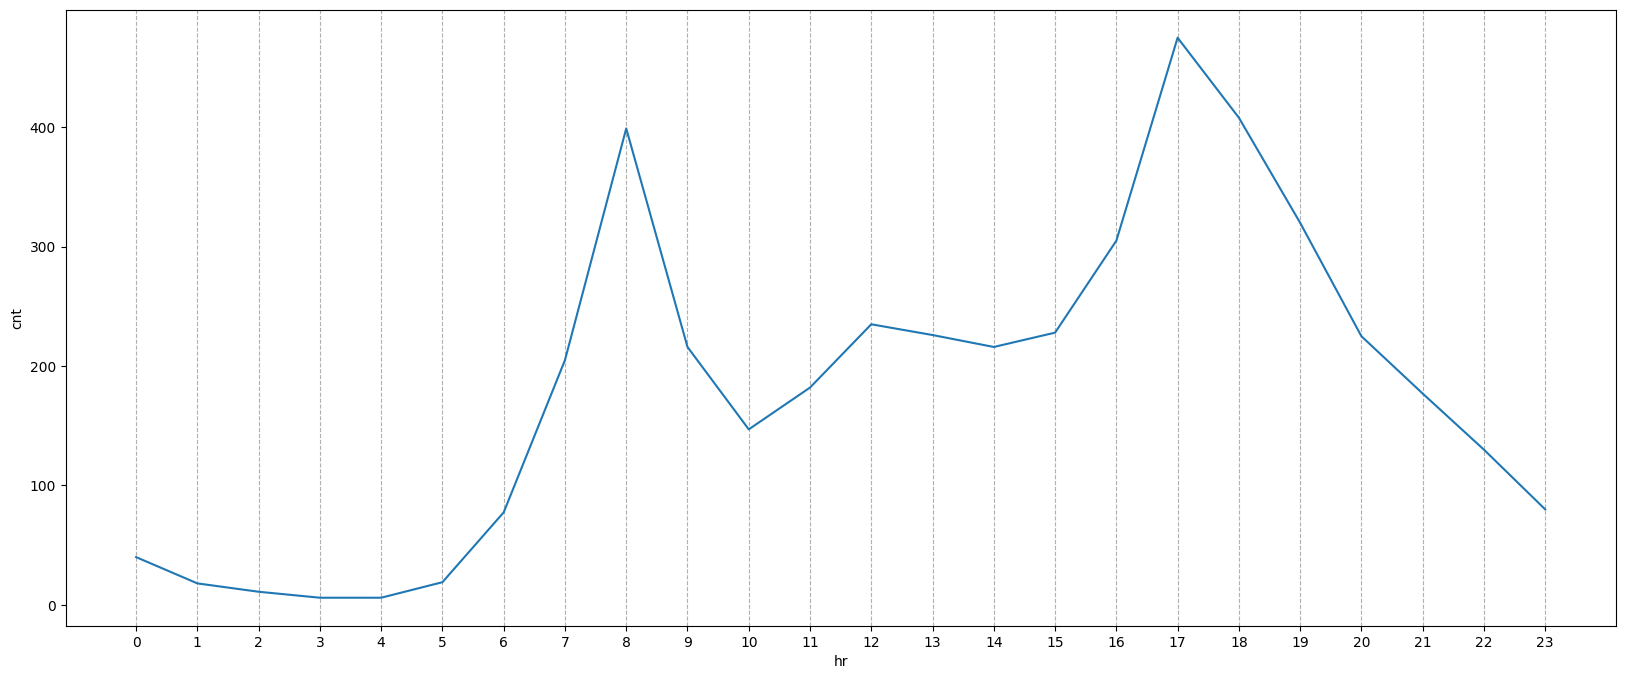

In [10]:
df_hr = df.groupby('hr')[['cnt']].median().reset_index()

plt.figure(figsize=(20,8))

ax = sns.lineplot(data=df_hr,x='hr',y='cnt')
ax.set_xticks(df_hr['hr'].values)
ax.grid(True, axis='x', linestyle='--')

plt.show()

- Nilai median cnt bersifat fluktuatif, terjadi kenaikan dari jam 7 hingga 9 (pagi) dan jam 16 hingga 18 (sore)
- Jam 7 hingga 9 merupakan waktu orang memulai aktifitas hari mereka, sedangkan jam 15 hingga 17 merupakan waktu orang pulang dari aktifitas mereka
- Penggunaan peminjaman sepeda naik disaat jam sibuk pagi dan sore (rush hour)

##### **Dampak Cuaca terhadap Cnt**

<Axes: xlabel='weathersit', ylabel='cnt'>

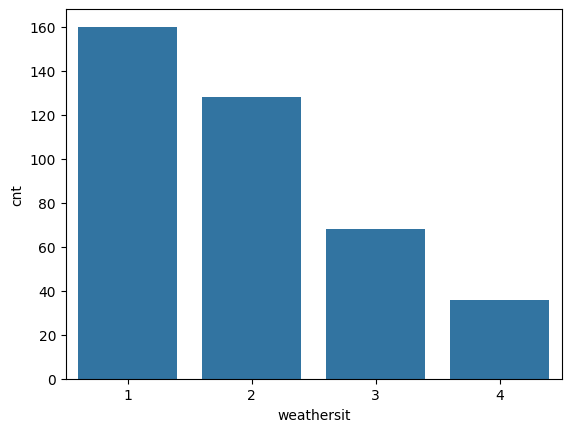

In [11]:
df_weather = df.groupby('weathersit')['cnt'].median().reset_index()
sns.barplot(data=df_weather, x='weathersit',y='cnt')

In [12]:
df_weather

,weathersit,cnt
0,1,160.0
1,2,128.0
2,3,68.0
3,4,36.0


nilai median cnt tertinggi adalah 1, nilai median cnt terendah adalah 4

penggunaan sepeda terbanyak terjadi ketika cuaca sedang cerah, sedangkan penggunaan sepeda terkecil terjadi ketika cuaca ekstrim

semakin buruk cuaca, minat konsumen untuk meminjam sepeda semakin turun

fitur temp dan atemp memiliki nilai korelasi yang tinggi terhadap nilai cnt

<Axes: xlabel='temp', ylabel='hum'>

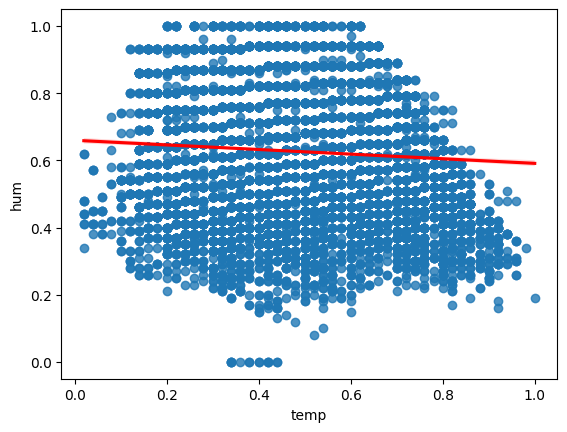

In [13]:
sns.regplot(data=df,x='temp',y='hum',line_kws={'color':'red'})

Berdasarkan regplot, humidity dan temperature memiliki hubungan negatif

Semakin tinggi suhu udara, semakin kecil kelembapan udara

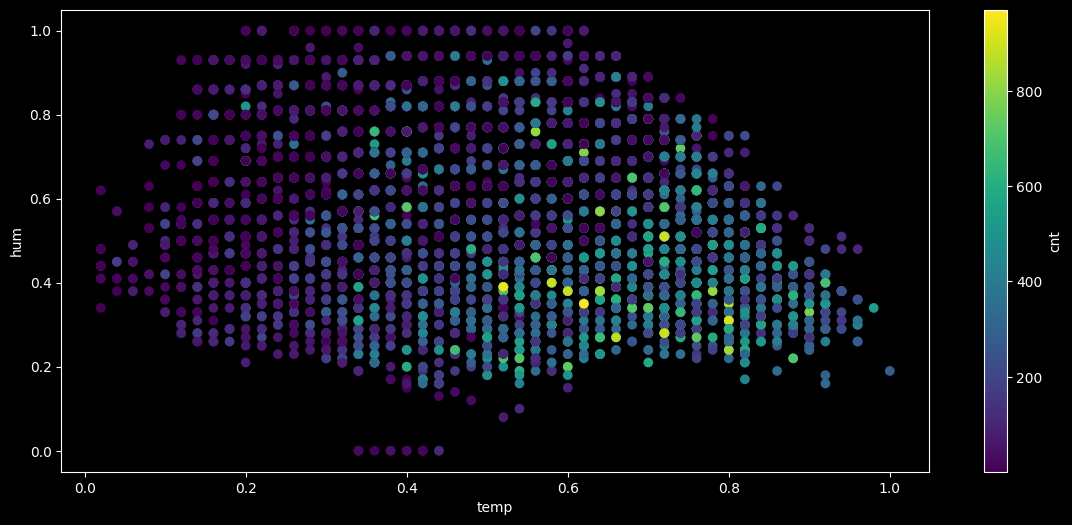

In [55]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(14,6))

    plt.scatter(data=df,x='temp',y='hum', c='cnt')
    plt.xlabel('temp')
    plt.ylabel('hum')

    cbar = plt.colorbar()
    cbar.set_label('cnt')


Pada scatter plot temp, hum, dan cnt dapat ditemukan bahwa nilai cnt cenderung naik ketika temp tinggi dan hum yang rendah

semakin tinggi suhu udara, semakin kecil kelembapan udara, maka demand peminjaman sepeda semakin tinggi

# **Data Preprocessing**

In [15]:
df_model = df.copy()

### **Feature Engineering**

Jumlah fitur pada dataset masih terbilang sedikit untuk sebuah model melakukan prediksi secara akurat. Dalam upaya menghindari underfitting, dilakukan pembuatan beberapa fitur baru dari fitur yang telah ada. Fitur-fitur baru yang akan ditambahkan merupakan fitur yang didapatkan berdasarkan domain knowledge dari proses exploratory data analysis.

In [16]:
df_model['day_of_week'] = df_model['dteday'].dt.dayofweek.astype(int)
df_model['day_of_month'] = df_model['dteday'].dt.day.astype(int)
df_model['month'] = df_model['dteday'].dt.month.astype(int)
df_model['year'] = df_model['dteday'].dt.year.astype(int)
df_model['weekday'] = df_model['day_of_week'].isin([0, 1, 2, 3, 4]).astype(int)
df_model.drop('dteday', axis=1, inplace=True)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hum           12165 non-null  float64
 1   weathersit    12165 non-null  int64  
 2   holiday       12165 non-null  int64  
 3   season        12165 non-null  int64  
 4   atemp         12165 non-null  float64
 5   temp          12165 non-null  float64
 6   hr            12165 non-null  int64  
 7   casual        12165 non-null  int64  
 8   registered    12165 non-null  int64  
 9   cnt           12165 non-null  int64  
 10  day_of_week   12165 non-null  int64  
 11  day_of_month  12165 non-null  int64  
 12  month         12165 non-null  int64  
 13  year          12165 non-null  int64  
 14  weekday       12165 non-null  int64  
dtypes: float64(3), int64(12)
memory usage: 1.4 MB


- fitur dteday dibagi menjadi 4 fitur, yaitu day of week, day of month, month, dan year untuk mempermudah proses pemodelan
- fitur weekday adalah fitur yang menjelaskan apabila hari tersebut merupakan hari kerja atau bukan

In [17]:
df_model['peak_hour'] = df_model['hr'].isin([7, 8, 9, 16, 17, 18]).astype(int)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hum           12165 non-null  float64
 1   weathersit    12165 non-null  int64  
 2   holiday       12165 non-null  int64  
 3   season        12165 non-null  int64  
 4   atemp         12165 non-null  float64
 5   temp          12165 non-null  float64
 6   hr            12165 non-null  int64  
 7   casual        12165 non-null  int64  
 8   registered    12165 non-null  int64  
 9   cnt           12165 non-null  int64  
 10  day_of_week   12165 non-null  int64  
 11  day_of_month  12165 non-null  int64  
 12  month         12165 non-null  int64  
 13  year          12165 non-null  int64  
 14  weekday       12165 non-null  int64  
 15  peak_hour     12165 non-null  int64  
dtypes: float64(3), int64(13)
memory usage: 1.5 MB


- fitur peak hour adalah fitur yang menjelaskan apabila peminjaman sepeda terjadi ketika peak hour (jam 7-9 pagi atau jam 4-6 sore) atau bukan

In [18]:
df_model['peak_season'] = df_model['season'].isin([2, 3]).astype(int)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hum           12165 non-null  float64
 1   weathersit    12165 non-null  int64  
 2   holiday       12165 non-null  int64  
 3   season        12165 non-null  int64  
 4   atemp         12165 non-null  float64
 5   temp          12165 non-null  float64
 6   hr            12165 non-null  int64  
 7   casual        12165 non-null  int64  
 8   registered    12165 non-null  int64  
 9   cnt           12165 non-null  int64  
 10  day_of_week   12165 non-null  int64  
 11  day_of_month  12165 non-null  int64  
 12  month         12165 non-null  int64  
 13  year          12165 non-null  int64  
 14  weekday       12165 non-null  int64  
 15  peak_hour     12165 non-null  int64  
 16  peak_season   12165 non-null  int64  
dtypes: float64(3), int64(14)
memory usage: 1.6 MB


- fitur peak season menjelaskan apabila peminjaman sepeda terjadi ketika musim paling sibuk untuk peminjaman sepeda (summer) atau bukan

In [19]:
mapping = {1:0.75,2:0.5,3:0.25,4:0.25}

df_model['temp_weight'] = df_model['weathersit'].map(mapping)
df_model['hum_weight'] = 1-df_model['temp_weight']
df_model['THI'] = (df_model['temp']*df_model['temp_weight'])+(df_model['hum']*df_model['hum_weight'])
df_model.drop(['temp_weight','hum_weight'],axis=1,inplace=True)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hum           12165 non-null  float64
 1   weathersit    12165 non-null  int64  
 2   holiday       12165 non-null  int64  
 3   season        12165 non-null  int64  
 4   atemp         12165 non-null  float64
 5   temp          12165 non-null  float64
 6   hr            12165 non-null  int64  
 7   casual        12165 non-null  int64  
 8   registered    12165 non-null  int64  
 9   cnt           12165 non-null  int64  
 10  day_of_week   12165 non-null  int64  
 11  day_of_month  12165 non-null  int64  
 12  month         12165 non-null  int64  
 13  year          12165 non-null  int64  
 14  weekday       12165 non-null  int64  
 15  peak_hour     12165 non-null  int64  
 16  peak_season   12165 non-null  int64  
 17  THI           12165 non-null  float64
dtypes: float64(4), int64(14)
m

THI (temperature humidity index) merupakan index untuk mengukur seberapa nyaman suatu cuaca (suhu udara, kelembapan udara, ) untuk dirasakan oleh manusia

$THI = (Temp*w1)+(Hum*w2)$

- Temp = Normalized Temperature
- Hum = Normalized Humidity
- w1 = Temperature Weight
- w2 = Humidity Weight

nilai bobot yang diberikan kepada temp dan hum berasal dari cuaca pada hari tersebut.
|cuaca|temp weight|hum weight|
|---|---|---|
| cuaca panas dan tidak terjadi hujan (weathersit=1)| 0.75 | 0.25 |
| cuaca berawan (weathersit=2)| 0.5 | 0.5 |
| terjadi hujan (weathersit=3)| 0.25| 0.75 |
| cuaca ekstrim, hujan badai atau berkabut (weathersit=3)| 0.25 | 0.75 |

Semakin ekstrim suatu cuaca (badai dan bersalju) -> suhu akan semakin kecil dan jumlah air yang ada pada udara semakin tinggi (semakin lembab).
Hal ini telah terbukti dari hubungan negatif pada regplot antara temp dan hum ketika proses EDA

Berikut merupakan fitur baru yang akan ditambahkan untuk proses modelling

| Fitur baru	| Deskripsi | Tipe Data |
|---|---|---|
| day of week	| urutan hari dalam minggu (0-6) | Integer |
| day of month	| urutan hari dalam bulan | Integer |
| month	| bulan | Integer |
| year	| tahun | Integer |
| weekday | 0: bukan hari kerja, 1: hari kerja | Integer |	
| peak hour | 0: bukan jam sibuk, 1: jam sibuk | Integer |
| peak season | 0: bukan musim sibuk, 1: musim sibuk |	Integer |
| THI	| temperature humidity index, index kenyamanan kondisi tempat tinggal berdasarkan suhu dan kelembapan | Float |

### **Drop Unnecessary Features**

Fitur cnt adalah jumlah total dari fitur casual dan registered, maka dari itu fitur casual dan registered tidak diperlukan untuk proses analisis selanjutnya

In [20]:
df_model.drop(['casual','registered'], axis=1, inplace=True)

In [21]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hum           12165 non-null  float64
 1   weathersit    12165 non-null  int64  
 2   holiday       12165 non-null  int64  
 3   season        12165 non-null  int64  
 4   atemp         12165 non-null  float64
 5   temp          12165 non-null  float64
 6   hr            12165 non-null  int64  
 7   cnt           12165 non-null  int64  
 8   day_of_week   12165 non-null  int64  
 9   day_of_month  12165 non-null  int64  
 10  month         12165 non-null  int64  
 11  year          12165 non-null  int64  
 12  weekday       12165 non-null  int64  
 13  peak_hour     12165 non-null  int64  
 14  peak_season   12165 non-null  int64  
 15  THI           12165 non-null  float64
dtypes: float64(4), int64(12)
memory usage: 1.5 MB


### **Outliers**

Text(0.5, 0.98, 'Distribution of Numerical Variables')

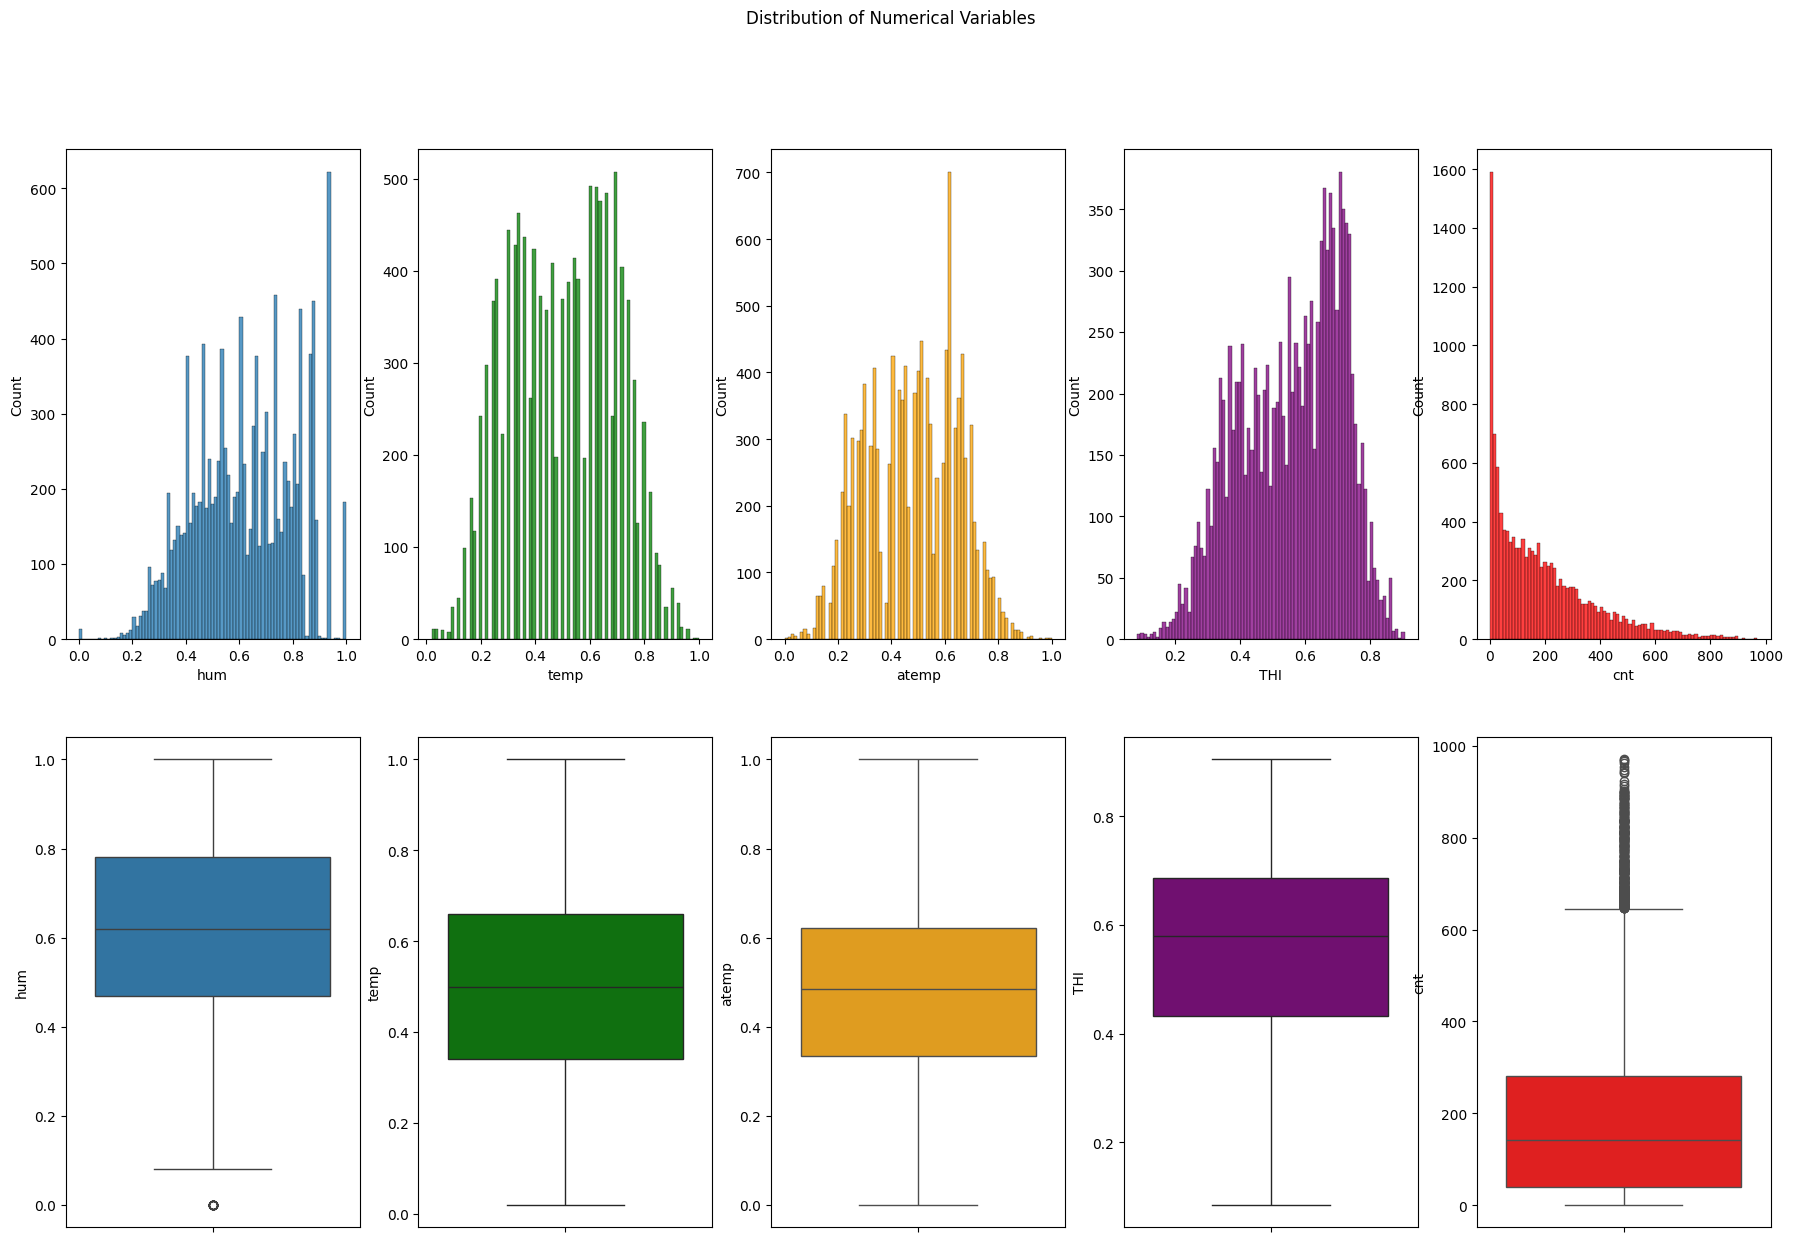

In [56]:
fig, axes = plt.subplots(2,5,figsize=(22,14))

sns.histplot(data=df_model,x='hum', ax=axes[0,0], bins=85)
sns.histplot(data=df_model,x='temp', ax=axes[0,1], color='green', bins=85)
sns.histplot(data=df_model,x='atemp', ax=axes[0,2], color='orange', bins=85)
sns.histplot(data=df_model,x='THI', ax=axes[0,3], color='purple', bins=85)
sns.histplot(data=df_model,x='cnt', ax=axes[0,4], color='red', bins=85)

sns.boxplot(data=df_model,y='hum', ax=axes[1,0])
sns.boxplot(data=df_model,y='temp', ax=axes[1,1],color='green')
sns.boxplot(data=df_model,y='atemp', ax=axes[1,2], color='orange')
sns.boxplot(data=df_model,y='THI', ax=axes[1,3], color='purple')
sns.boxplot(data=df_model,y='cnt', ax=axes[1,4], color='red')

fig.suptitle('Distribution of Numerical Variables')

Berdasarkan boxplot dan histogram diatas, variabel cnt dan temp_weather_interaction memiliki banyak outlier. Fitur numerikal (hum, temp, atemp) telah dinormalisasi sehingga tidak perlu melalui pemeriksaan outlier

In [23]:
def outlier_stats(feature):
    q1 = df_model[feature].quantile(0.25)
    q3 = df_model[feature].quantile(0.75)
    iqr = q3 - q1
    limit = iqr * 1.5
    upper_bound = q3 + limit
    lower_bound = q1 - limit
    
    print(f'iqr: {iqr}')
    print(f'upper_bound: {upper_bound}')
    print(f'lower_bound: {lower_bound}')

##### **Humidity**

In [24]:
outlier_stats('hum')

iqr: 0.31000000000000005
upper_bound: 1.245
lower_bound: 0.004999999999999893


In [25]:
df_model[df_model['hum']<0.0149].count()['hum']

np.int64(14)

Terdapat 14 baris data yang memiliki hum diatas upper bound, maka dari itu data tersebut tidak akan diikutsertakan kedalam model machine learning.

##### **Cnt**

In [26]:
outlier_stats('cnt')

iqr: 242.0
upper_bound: 645.0
lower_bound: -323.0


In [27]:
df_model[df_model['cnt']>645].count()['cnt']

np.int64(338)

Terdapat 338 baris data yang memiliki cnt diatas upper bound, maka dari itu data tersebut tidak akan diikutsertakan kedalam model machine learning agar mengurangi skewness pada distribusi data.

##### **Drop Outliers**

In [28]:
df_model_after = df_model.copy()

In [29]:
df_model_after = df_model_after[df_model_after['cnt']<=645]
df_model_after = df_model_after[df_model_after['hum']>=0.0149]

##### **Data Comparison With and Without Outliers**

In [30]:
df_model_after.describe()

,hum,weathersit,holiday,season,atemp,temp,hr,cnt,day_of_week,day_of_month,month,year,weekday,peak_hour,peak_season,THI
count,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000,11813.000000
mean,0.629196,1.420808,0.030560,2.478033,0.473517,0.494350,11.438585,173.384238,3.014983,15.648946,6.487514,2011.488360,0.710827,0.233556,0.509354,0.558139
std,0.190793,0.637812,0.172128,1.109465,0.171964,0.192538,6.979256,155.931763,1.999457,8.806904,3.455726,0.499886,0.453398,0.423111,0.499934,0.156402
min,0.080000,1.000000,0.000000,1.000000,0.000000,0.020000,0.000000,1.000000,0.000000,1.000000,1.000000,2011.000000,0.000000,0.000000,0.000000,0.100000
25%,0.480000,1.000000,0.000000,1.000000,0.333300,0.340000,5.000000,38.000000,1.000000,8.000000,3.000000,2011.000000,0.000000,0.000000,0.000000,0.427500
50%,0.630000,1.000000,0.000000,2.000000,0.484800,0.500000,11.000000,136.000000,3.000000,16.000000,6.000000,2011.000000,1.000000,0.000000,1.000000,0.580000
75%,0.790000,2.000000,0.000000,3.000000,0.621200,0.660000,18.000000,267.000000,5.000000,23.000000,9.000000,2012.000000,1.000000,0.000000,1.000000,0.687500
max,1.000000,4.000000,1.000000,4.000000,1.000000,1.000000,23.000000,645.000000,6.000000,31.000000,12.000000,2012.000000,1.000000,1.000000,1.000000,0.905000


In [31]:
df_model_after.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11813 entries, 0 to 12164
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hum           11813 non-null  float64
 1   weathersit    11813 non-null  int64  
 2   holiday       11813 non-null  int64  
 3   season        11813 non-null  int64  
 4   atemp         11813 non-null  float64
 5   temp          11813 non-null  float64
 6   hr            11813 non-null  int64  
 7   cnt           11813 non-null  int64  
 8   day_of_week   11813 non-null  int64  
 9   day_of_month  11813 non-null  int64  
 10  month         11813 non-null  int64  
 11  year          11813 non-null  int64  
 12  weekday       11813 non-null  int64  
 13  peak_hour     11813 non-null  int64  
 14  peak_season   11813 non-null  int64  
 15  THI           11813 non-null  float64
dtypes: float64(4), int64(12)
memory usage: 1.5 MB


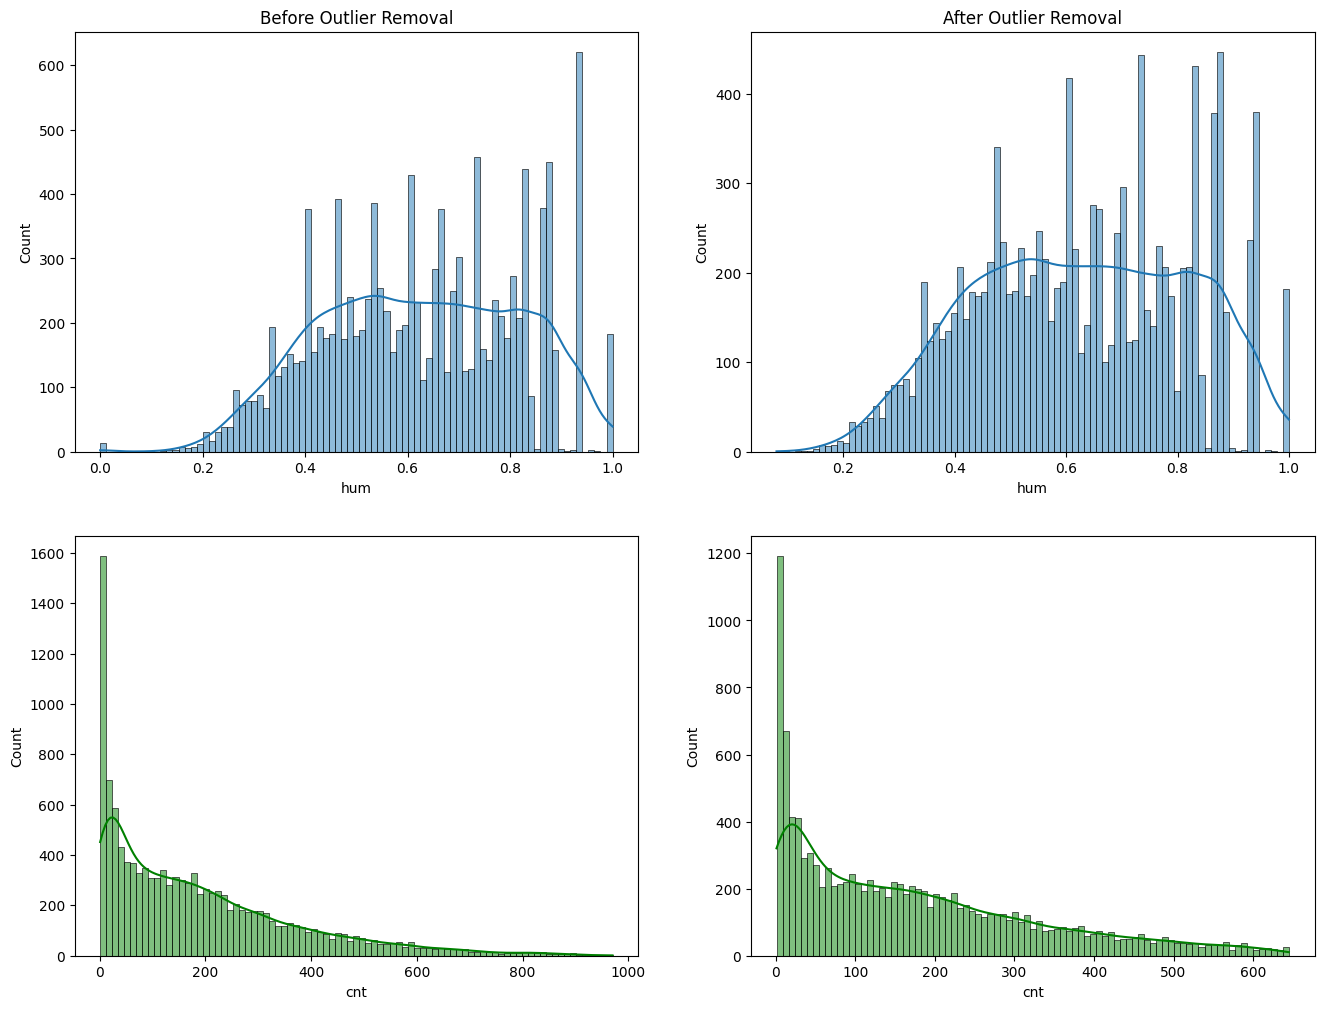

In [32]:
fig, axes = plt.subplots(2,2,figsize=(16,12))
plt.style.use('default')

sns.histplot(data=df_model,x='hum', ax=axes[0,0], bins=85, kde=True)
sns.histplot(data=df_model_after,x='hum', ax=axes[0,1], bins=85, kde=True)

sns.histplot(data=df_model,x='cnt', ax=axes[1,0], bins=85, kde=True, color='green')
sns.histplot(data=df_model_after,x='cnt', ax=axes[1,1], bins=85, kde=True, color='green')

axes[0,0].set_title('Before Outlier Removal')
axes[0,1].set_title('After Outlier Removal')
plt.show()

Setelah outlier dari kedua variabel tersebut dibuang, skewness pada distribusi data variabel target (cnt) dan fitur hum berkurang sedikit

### **Splitting Features and Target**

In [33]:
features = df_model_after.drop('cnt', axis=1)
target = df_model_after['cnt']

X = features
y = target

In [34]:
num_features = ['hum','temp','atemp','THI']
cat_features = df_model_after.drop(num_features + ['cnt'], axis=1).columns.tolist()

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

### **Build Preprocessors for Pipeline**

In [36]:
preprocessor_a = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', StandardScaler(), num_features)
])

preprocessor_b = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), ['season','holiday','weathersit']),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['hr','day_of_month','year','day_of_week']),
    ('num', StandardScaler(), num_features)
])

Terdapat 2 preprocessor dengan metode encoding yang berbeda dalam upaya mencari transform yang optimal untuk proses benchmark model.

**1. preprocessor_a**
- semua fitur kategori akan diubah menjadi fitur numerik dengan one hot encoding
- dilakukan scaling pada fitur numerik menggunakan standard scaler

**2. preprocessor_b**
- fitur yang berhubungan dengan waktu (hr,day of week, day of month, month, year) akan diubah dengan ordinal encoding karena waktu memiliki urutan, sedangkan fitur lainnya menggunakan one hot encoding
- dilakukan scaling pada fitur numerik menggunakan standard scaler

**Penggunaan encoder yang berbeda dibutuhkan karena setiap algoritma yang ada pada proses benchmark memiliki respon yang berbeda terhadap encoder berbeda**

# **Modelling**

### **Splitting Data Into Test and Training Datasets**

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

### **Models Benchmark**

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.compose import TransformedTargetRegressor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor

In [40]:
#membuat function untuk benchmark model
def benchmark_model(preprocessor):

    #Memilih model yang akan digunakan untuk proses benchmark
    lr = LinearRegression()
    knn = KNeighborsRegressor()
    dt = DecisionTreeRegressor(random_state=42)
    rf = RandomForestRegressor(random_state=42)
    xgb = XGBRegressor(random_state=42)

    models = [lr, knn, dt, rf, xgb]
    
    #membuat list kosong untuk menyimpan hasil cross validation tiap model
    #rmse
    score_rmse = []
    mean_rmse = []
    std_rmse = []
    #mae
    score_mae = []
    mean_mae = []
    std_mae = []
    #MAPE
    score_mape = []
    mean_mape = []
    std_mape = []

#iteration untuk melakukan cross validation pada tiap model
    for model in models:
        
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        #membuat pipeline estimator untuk preprocessing dan modeling
        estimator = Pipeline([
            ('preprocessing', preprocessor),
            ('model', model)
            ])
        
        lt_estimator = TransformedTargetRegressor(regressor=estimator, func=np.log1p, inverse_func=np.expm1)
        
        #melakukan cross validation dengan metrics rmse, mae, mape, dan MAPE
        cv_rmse = cross_val_score(lt_estimator, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', error_score='raise')
        cv_mae = cross_val_score(lt_estimator, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error', error_score='raise')
        cv_mape = cross_val_score(lt_estimator, X_train, y_train, cv=cv, scoring='neg_mean_absolute_percentage_error', error_score='raise')
    
        #menyimpan hasil cross validation tiap model kedalam list
        score_rmse.append(cv_rmse)
        mean_rmse.append(np.mean(cv_rmse))
        std_rmse.append(np.std(cv_rmse))
        
        score_mae.append(cv_mae)
        mean_mae.append(np.mean(cv_mae))
        std_mae.append(np.std(cv_mae))
        
        score_mape.append(cv_mape)
        mean_mape.append(np.mean(cv_mape))
        std_mape.append(np.std(cv_mape))
    
    #membuat dataframe untuk menyimpan hasil benchmark model    
    metrics = pd.DataFrame({
        'Model': ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost'],
        'Mean RMSE': mean_rmse,
        'Std RMSE': std_rmse,
        'Mean MAE': mean_mae,
        'Std MAE': std_mae,
        'Mean MAPE': mean_mape,
        'Std MAPE': std_mape,
    })
    
    return metrics.sort_values(by='Mean RMSE', ascending=False)

In [41]:
benchmark_model(preprocessor_a)

,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE,Mean MAPE,Std MAPE
3,Random Forest,-47.017786,1.264616,-29.070522,0.978172,-0.313038,0.014259
4,XGBoost,-47.538754,1.044942,-29.524545,0.260277,-0.290002,0.012890
2,Decision Tree,-63.405813,3.372744,-38.490723,1.921150,-0.434471,0.007904
0,Linear Regression,-87.424814,2.496415,-57.795266,1.741889,-0.607708,0.030346
1,KNN,-117.097856,2.001537,-79.927502,1.463109,-1.743022,0.115966


In [42]:
benchmark_model(preprocessor_b)

,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE,Mean MAPE,Std MAPE
4,XGBoost,-42.668906,1.473538,-26.294536,0.766653,-0.265917,0.017933
3,Random Forest,-47.906797,1.649684,-29.240799,0.724260,-0.306375,0.019116
2,Decision Tree,-65.491899,2.284319,-39.668310,0.568297,-0.467534,0.038522
1,KNN,-74.706086,2.103204,-47.678410,1.163569,-0.506621,0.029006
0,Linear Regression,-141.251602,3.304966,-96.354871,1.897046,-1.402867,0.041215


Setelah dilakukan benchmark dengan 5 kandidat model dan 2 preprocessor yang berbeda, didapatkan hasil yang menunjukan bahwa :

- Nilai RMSE lebih besar dibandingkan nilai MAE, menandakan bahwa model membuat kesalahan prediksi yang cukup tinggi
- Random Forest menjadi model dengan RMSE dan MAE terkecil menggunakan preprocessor a(menggunakan one hot encoder dan standard scaler)
- XGBoost menjadi model dengan RMSE, MAE, dan MAPE terkecil menggunakan preprocessor b (menggunakan one hot encoder, ordinal encoder, dan standard scaler)

**XGBoost adalah model yang terpilih karena memiliki performa terbaik berdasarkan ketiga metrics**

In [43]:
xgb = XGBRegressor(random_state=42)

score_rmse = []
score_mae = []
score_mape = []

model_pip = Pipeline([
    ('preprocessing', preprocessor_b),
    ('model', xgb)
    ])

model_pip.fit(X_train, y_train)
y_pred = model_pip.predict(X_test)
score_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
score_mae.append(mean_absolute_error(y_test, y_pred))
score_mape.append(mean_absolute_percentage_error(y_test, y_pred))

score_before_tuning = pd.DataFrame({'Model':'XGBoost','RMSE': score_rmse, 'MAE': score_mae, 'MAPE': score_mape})
score_before_tuning

,Model,RMSE,MAE,MAPE
0,XGBoost,42.494206,26.913054,0.465368


### **Hyperparameter Tuning**

Dalam upaya mendapatkan performa model yang lebih baik, perlu menggunakan hyperparameter yang tepat agar performa model lebih optimal.

In [44]:
# Kedalaman pohon
max_depth = list(np.arange(1, 11))

# Learning rate
learning_rate = list(np.arange(1, 100)/100)

# Jumlah pohon
n_estimators = list(np.arange(100, 201))

# Jumlah baris tiap pohon (% dari total baris train set)
subsample = list(np.arange(2, 10)/10)

# Gamma (min_impurity_decrease)
gamma = list(np.arange(1, 11)) # Semakin besar nilainya, semakin konservatif/simpel modelnya

# Jumlah feature yang digunakan untuk tiap pohon (% dari total kolom train set)
colsample_bytree = list(np.arange(1, 10)/10)

# Alpha (regularization)
reg_alpha = list(np.logspace(-3, 1, 10)) # Semakin besar nilainya, semakin konservatif/simpel modelnya


# Hyperparam space XGboost
hyperparam_space_xgb = {
    'model__max_depth': max_depth, 
    'model__learning_rate': learning_rate,
    'model__n_estimators': n_estimators,
    'model__subsample': subsample,
    'model__gamma': gamma,
    'model__colsample_bytree': colsample_bytree,
    'model__reg_alpha': reg_alpha
}

Hyperparameter tuning menggunakan metode Randomized Search karena hyperparameter pada model cukup banyak

In [45]:
# Benchmark model dengan hyperparameter tuning
xgb = XGBRegressor(random_state=42, verbosity=0)

# Membuat algorithm chains
estimator_xgb = Pipeline([
        ('preprocessing', preprocessor_b),
        ('model', xgb)
        ])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter tuning
random_xgb = RandomizedSearchCV(
    estimator_xgb, 
    param_distributions = hyperparam_space_xgb,
    n_iter = 200,
    cv = cv, 
    scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'], 
    n_jobs = -1,
    refit = 'neg_root_mean_squared_error', # Hanya bisa memilih salah stau metric untuk optimisasi
    random_state = 42  
)

In [46]:
# Fitting data training untuk mencari parameter terbaik
random_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [np.float64(0.1), np.float64(0.2), ...], 'model__gamma': [np.int64(1), np.int64(2), ...], 'model__learning_rate': [np.float64(0.01), np.float64(0.02), ...], 'model__max_depth': [np.int64(1), np.int64(2), ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['neg_root_mean_squared_error', 'neg_mean_absolute_error', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` i

In [47]:
random_xgb_result = pd.DataFrame(random_xgb.cv_results_).sort_values(by=['rank_test_neg_root_mean_squared_error', 'rank_test_neg_mean_absolute_error', 'rank_test_neg_mean_absolute_percentage_error']).head()
random_xgb_result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__reg_alpha,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__gamma,...,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error,split0_test_neg_mean_absolute_percentage_error,split1_test_neg_mean_absolute_percentage_error,split2_test_neg_mean_absolute_percentage_error,split3_test_neg_mean_absolute_percentage_error,split4_test_neg_mean_absolute_percentage_error,mean_test_neg_mean_absolute_percentage_error,std_test_neg_mean_absolute_percentage_error,rank_test_neg_mean_absolute_percentage_error
114,0.333981,0.011692,0.014007,0.001998,0.6,0.059948,192,7,0.09,10,...,0.544227,1,-0.380099,-0.366203,-0.387919,-0.436296,-0.394984,-0.393100,0.023617,2
102,0.231731,0.003623,0.011600,0.000489,0.3,0.021544,181,6,0.12,2,...,0.453629,4,-0.517426,-0.493766,-0.487085,-0.584938,-0.537400,-0.524123,0.035250,6
101,0.189263,0.017329,0.011401,0.001496,0.8,0.007743,154,6,0.24,9,...,0.650334,5,-0.618774,-0.474955,-0.521907,-0.626568,-0.589745,-0.566390,0.058737,8
134,0.520081,0.009848,0.015570,0.001025,0.8,0.001000,169,10,0.24,4,...,0.764766,3,-0.414623,-0.360651,-0.398282,-0.440942,-0.441418,-0.411183,0.030105,3
9,0.112550,0.009237,0.009013,0.000545,0.9,0.059948,105,5,0.38,3,...,0.139221,7,-0.676622,-0.519967,-0.533529,-0.691779,-0.688529,-0.622085,0.078124,15


In [48]:
# Cek skor dan params terbaik
print('XGBoost')
print('Best_score:', random_xgb.best_score_)
print('Best_params:', random_xgb.best_params_)

XGBoost
Best_score: -39.063550567626955
Best_params: {'model__subsample': np.float64(0.6), 'model__reg_alpha': np.float64(0.05994842503189409), 'model__n_estimators': np.int64(192), 'model__max_depth': np.int64(7), 'model__learning_rate': np.float64(0.09), 'model__gamma': np.int64(10), 'model__colsample_bytree': np.float64(0.9)}


### **Model Fitting**

In [49]:
# Define model terhadap estimator terbaik
xgb_tuning = random_xgb.best_estimator_

# Fitting model
xgb_tuning.fit(X_train, y_train)

# Predict test set
y_pred_xgb_tuning = xgb_tuning.predict(X_test)

# Simpan nilai metrics RMSE, MAE & MAPE setelah tuning
rmse_xgb_tuning = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuning))
mae_xgb_tuning = mean_absolute_error(y_test, y_pred_xgb_tuning)
mape_xgb_tuning = mean_absolute_percentage_error(y_test, y_pred_xgb_tuning)

score_after_tuning = pd.DataFrame({'Model': 'XGBoost', 'RMSE': rmse_xgb_tuning, 'MAE': mae_xgb_tuning, 'MAPE': mape_xgb_tuning}, index=[0])
score_after_tuning

,Model,RMSE,MAE,MAPE
0,XGBoost,40.487977,25.009029,0.40792


### **Model Performance Comparison**

In [50]:
score_before_tuning

,Model,RMSE,MAE,MAPE
0,XGBoost,42.494206,26.913054,0.465368


In [51]:
score_after_tuning

,Model,RMSE,MAE,MAPE
0,XGBoost,40.487977,25.009029,0.40792


Hyperparameter tuning efektif dalam megurangi nilai RMSE, MAE, dan MAPE.

### **Model Evaluation**

[Text(0.5, 1.0, 'Residual Distribution'),
 Text(0.5, 0, 'Residuals'),
 Text(0, 0.5, 'Frequency')]

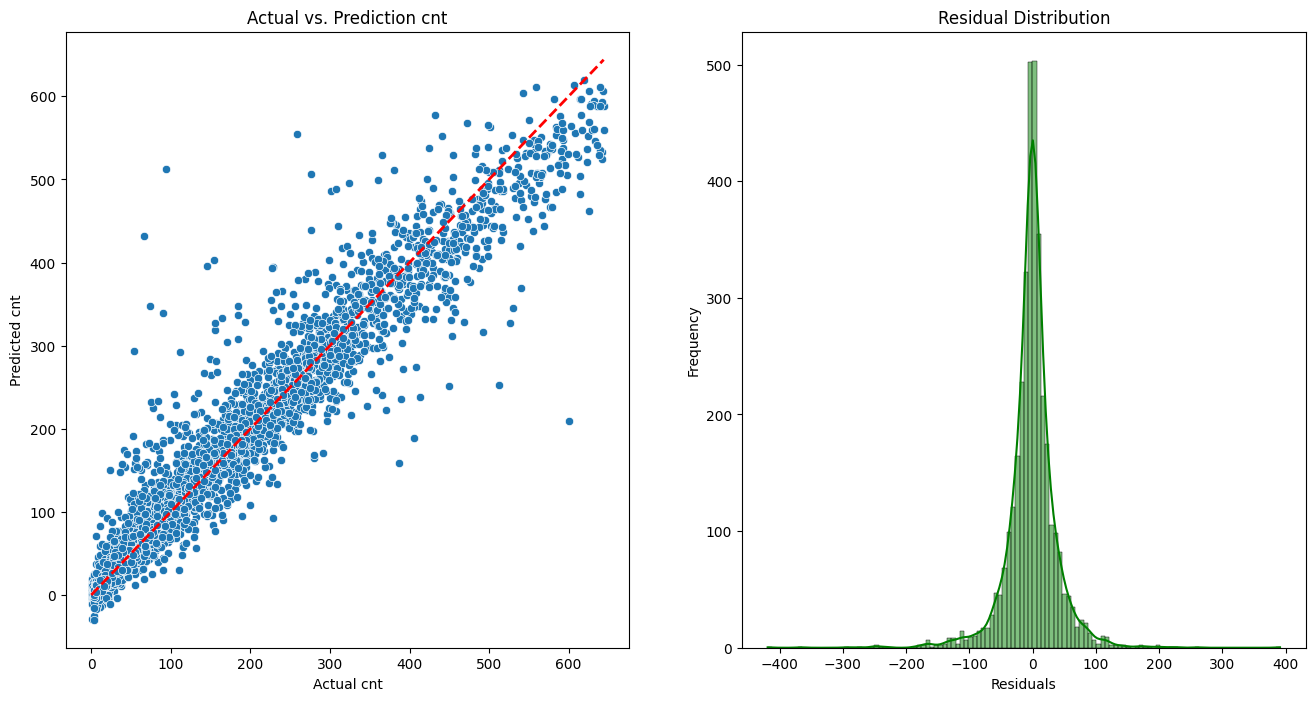

In [52]:
fig, ax = plt.subplots(1,2, figsize=(16, 8))

#actual vs prediction cnt
ax1= sns.scatterplot(x=y_test, y=y_pred_xgb_tuning, ax=ax[0])
ax1.set(title='Actual vs. Prediction cnt', xlabel='Actual cnt', ylabel='Predicted cnt')
#membuat garis diagonal untuk menunjukkan prediksi yang sempurna
lims = [0, max(y_test.max(), y_pred_xgb_tuning.max())]
ax1.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')

#residual distribution plot
residuals = y_test - y_pred_xgb_tuning
ax2 = sns.histplot(residuals, kde=True, ax=ax[1], color='green')
ax2.set(title='Residual Distribution', xlabel='Residuals', ylabel='Frequency')

RMSE merupakan *metric* yang memberikan penalti lebih berat terhadap *error* yang tinggi. Berdasarkan scatterplot data aktual dan data prediksi, terdapat beberapa nilai *outlier*. Hal ini merupakan salah satu faktor yang menyebabkan nilai RMSE jauh lebih tinggi dari nilai MAE.

Distribusi data residual yang normal memiliki arti bahwa model memberikan prediksi lebih tinggi dibandingkan data aktual (*overestimation*) dan prediksi lebih rendah dari data aktual (*underestimation*) secara seragam.

### **Feature Importances**

Dibuat plot untuk menjelaskan fitur-fitur apa saja yang paling mempengaruhi demand peminjaman sepeda.

<Axes: title={'center': 'Feature Importances'}>

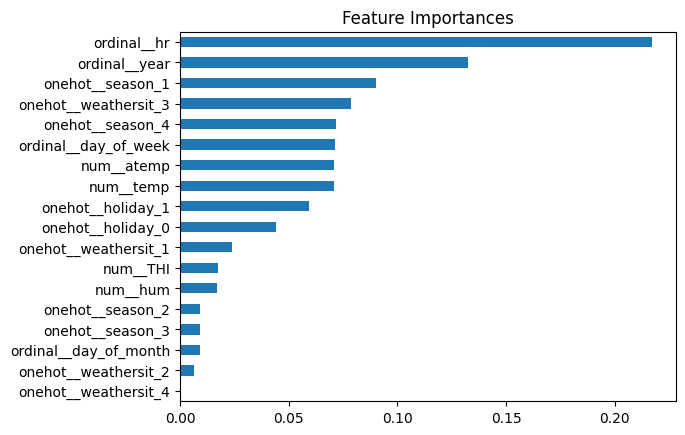

In [53]:
feature_imp = pd.Series(xgb_tuning['model'].feature_importances_, preprocessor_b.get_feature_names_out()).sort_values()
feature_imp.plot(kind='barh', title='Feature Importances')

# **Conclusion & Recommendation**

### **Conclusion**

#### **Feature Importances**

Setelah melakuan pemodelan, terdapat beberapa fitur yang memiliki pengaruh yang besar terhadap demand peminjaman sepeda. fitur hr (jam), year(tahun), dan season (musim) berkontribusi besar terhadap jumlah demand peminjaman sepeda. Feature engineering dengan menambahkan fitur baru dapat memperlihatkan pola-pola perilaku konsumen yang tidak dapat terlihat di raw data. Day_of_week (hari) memiliki pengaruh yang signifikan terhadap demand peminjaman sepeda, jenis hari dalm satu minggu dapat menentukan jumlah demand.



##### **Model Performance & Limitation**

Nilai RMSE yang dihasilkan model bernilai lebih tinggi dari MAE, hal ini disebabkan karena model membuat beberapa kesalahan prediksi jauh dari data aktual. Dalam melakukan prediksi demand peminjaman sepeda terhadap data dengan rentang nilai 0 - 645, rata-rata prediksi model meleset sebesar 40 dari jumlah demand sebenarnya jika mempertimbangkan outlier. Sedangkan MAPE sebesar 40% berarti model mampu melakukan prediksi demand peminjaman sepeda dengan kesalahan sebesar 40% dari demand aktual.

##### **Cost-Benefit Analysis**

1. Cost (1 bulan)

| Jenis Biaya | Nilai |
|---|---|
| Infrastruktur machine learning (cloud database) | 45.000.000 |
| Pengembangan model | 120.000.000 |
| Software dan tools | 30.000.000 |
| Integrasi deployment | 60.000.000 |
| Maintenance | 22.500.000 |
| **Total** | **277.500.000** |

2. Benefit (1 bulan)

| Jenis Manfaat | Sebelum model | Setelah model | Nilai |
|---|---|---|---|
| Pengurangan sepeda tidak terpakai | 173 sepeda (3.000.000 per sepeda) disediakan, berdasarkan rata-rata demand | 140 sepeda disediakan berdasarkan prediksi model (demand aktual sebesar 100 dan RMSE = 40) |(173 X 3.000.000) - (140 X 3.000.000) = 99.000.000 |
| Efisiensi staff operasional | 9 staff operasional (400.000 per jam)| 7 staff operasional | jika 100 sepeda membutuhkan 5 staff maka (9 X 400.000) - (7 X 400.000) = 800.000 per jam (576.000.000 per bulan) |
| Efisiensi biaya operasional (logistik dan bahan bakar) | 173 sepeda (50.000 per sepeda)| 140 sepeda (demand aktual sebesar 100 dan RMSE = 40) | (173 X 10.000)-(140 X 10.000) = 330.000 per jam (237.600.000 per bulan) |
| **Total** |---|---| **912.600.000** |

3. Net Benefit

$Net Benefit = Total Benefit - Total Cost$

$Net Benefit = 912.600.000 - 277.500.000$

$Net Benefit = 635.100.000 (Positive ROI)$

Berdasarkan contoh perhitungan terseebut, proyek ini dinyatakan layak untuk dilaksanakan karena memiliki ROI yang positif, proyek dapat menghemat biaya yang sangat besar


### **Recommendations**

Berikut merupakan saran-saran yang dapat membantu dalam membantu dalam meningkatkan bisnis bike-sharing.

1. Menerapkan data-driven decision dengan merencanakan pengadaan fasilitas di setiap stasiun bike-sharing berdasarkan hasil prediksi model machine learning. Hal ini dapat membantu perusahaan dalam meminimalisasi kerugian karena oversupply, serta pengelola mampu membuat jadwal maintenance yang lebih strategis berdasarkan hasil prediksi demand yang rendah.

2. Menambahkan fitur-fitur baru yang mempunyai potensi memiliki korelasi dengan jumlah demand agar dapat membangun model machine learning yang lebih kompleks dan terhindar dari underfitting, seperti fitur geografis berupa titik kordinat (garis lintang dan garis bujur) stasiun bike-sharing, fitur nama area, dan fitur jarak menuju stasiun bike-sharing terdekat.

3. Model memiliki skor RMSE yang lebih tinggi dibandingkan MAE, outlier yang tinggi pada selisih data aktual dengan prediksi menyebabkan model kesulitan melakukan prediksi yang stabil ketika terdapat kenaikan dan penurunan demand secara signifikan. Dalam upaya meningkatkan performa model, pilih overestimation dan underestimation dengan nilai residual tertinggi, masing-masing sejumlah 5% dari total data. Selanjutnya adalah melakukan obesrvasi terhadap hubungan antara setiap variabel untuk mencari faktor apa saja yang menyebabkan error tinggi.